In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# User defined modules
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
from E9_fn import util

c:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\.venv\Lib\site-packages\gftool\precision.py:16: UserWarning: No quad precision datatypes available!
Some functions might be less accurate.
  warnings.warn("No quad precision datatypes available!\n"


In [2]:
def S_flatband(nu):
    return -(1 - nu) * np.log(1 - nu) - nu * np.log(nu)

In [3]:
cmap = plt.get_cmap('coolwarm')

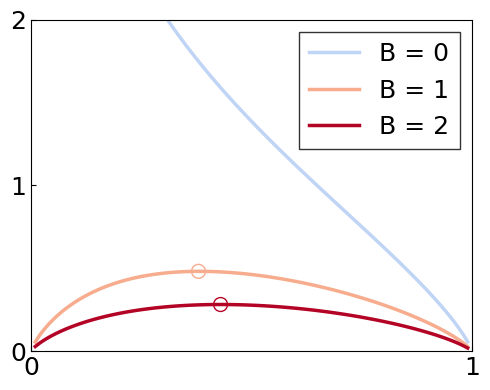

In [17]:
fig_s, ax_s = plt.subplots(figsize = (5, 4))
nus = np.linspace(0.01, 0.99, 99)
all_B = [B for B in range(3)]
for B in all_B:
    B_color = util.get_color(B, all_B, cmap, assignment = "index", crange = (0.4, 1))
    s_rsv = S_flatband(nus) / (nus + B)
    ax_s.plot(nus, s_rsv, label = f"B = {B}", color = B_color, lw = 2.5)
    inflection_pts = util.find_sign_change(util.find_derivative(s_rsv))
    ax_s.scatter(nus[inflection_pts], s_rsv[inflection_pts], s = 100,
                 marker = 'o', facecolors = "None", edgecolors = B_color)

# ax_s.hlines([0.5], 0, 1, color = 'k', ls = "--")    # lowest s achieved with evap cooling
ax_s.legend(loc = "upper right", fancybox = False, edgecolor = "black", fontsize = 18)
ax_s.set_xlim((0, 1))
ax_s.tick_params(direction = 'in', labelsize = 18)
ax_s.set_xticks(np.linspace(0, 1, 2))
ax_s.set_ylim((0, 2))
ax_s.set_yticks(np.linspace(0, 2, 3))
# ax_s.set_xlabel(r"$n_R$", fontsize = 10)
# ax_s.set_ylabel(r"$\sigma_R/k_B$", fontsize = 10)
fig_s.tight_layout()